# Phân tích Giá và Hành vi Đặt Xe (Customer Price Acceptance)

Mục tiêu của notebook này là phân tích bộ dữ liệu tổng hợp (`data/customer_synthetic_trips.csv`) để:
1. Hiểu cách hệ thống định giá (Linear Regression trên `delta_price`).
2. Phân tích xác suất khách hàng đồng ý đặt xe (Logistic Regression trên `customer_accept`).
3. Khám phá ảnh hưởng của **Giá (Price)**, **Mưa (Rain)**, và **Giờ Cao Điểm (Rush Hour)** đến quyết định đặt xe từ góc nhìn của khách hàng.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score
from pathlib import Path

sns.set_theme(style="whitegrid")
DATA_PATH = Path("../data/customer_synthetic_trips.csv")
df = pd.read_csv(DATA_PATH)

# Định nghĩa 4 ngữ cảnh
def get_context(row):
    if row['rain'] == 0 and row['rush_hour'] == 0: return '1. Khong Mua - Binh Thuong'
    if row['rain'] == 1 and row['rush_hour'] == 0: return '2. Mua - Binh Thuong'
    if row['rain'] == 0 and row['rush_hour'] == 1: return '3. Khong Mua - Cao Diem'
    if row['rain'] == 1 and row['rush_hour'] == 1: return '4. Mua - Cao Diem'

df['context'] = df.apply(get_context, axis=1)

# Thống kê tổng quan
display(df[['final_price', 'customer_accept_prob', 'customer_accept']].describe())


,final_price,customer_accept_prob,customer_accept
count,5000.000000,5000.000000,5000.000000
mean,58905.141200,0.747406,0.742200
std,20285.201603,0.167205,0.437467
min,11349.000000,0.087100,0.000000
25%,43837.750000,0.650475,0.000000
50%,58031.500000,0.785400,1.000000
75%,72795.750000,0.876425,1.000000
max,128866.000000,0.991400,1.000000


> **💡 Giải thích kết quả:** Các thống kê cơ bản này xác nhận tập dữ liệu mô phỏng hoạt động tốt. Cột `customer_accept` là biến nhị phân (0 hoặc 1), cho biết khách hàng có đồng ý giá đó không. Mức `customer_accept_prob` dao động từ cực thấp đến cực cao cho phép mô hình Logistic học được biên giới quyết định (decision boundary).

## 1. Phân tích giá (Delta Price) bằng Linear Regression
Tương tự như dữ liệu tài xế, chúng ta sử dụng `Linear Regression` để trích xuất các hệ số ($\beta$) của mô hình định giá:
$$\Delta P_i = \beta_0 + \beta_1 \cdot \text{rain}_i + \beta_2 \cdot \text{rush\_hour}_i$$

Beta0 (Intercept - Khong Mua/Binh thuong): 1,938 VND
Beta1 (Rain effect): 7,906 VND
Beta2 (Rush Hour effect): 12,110 VND


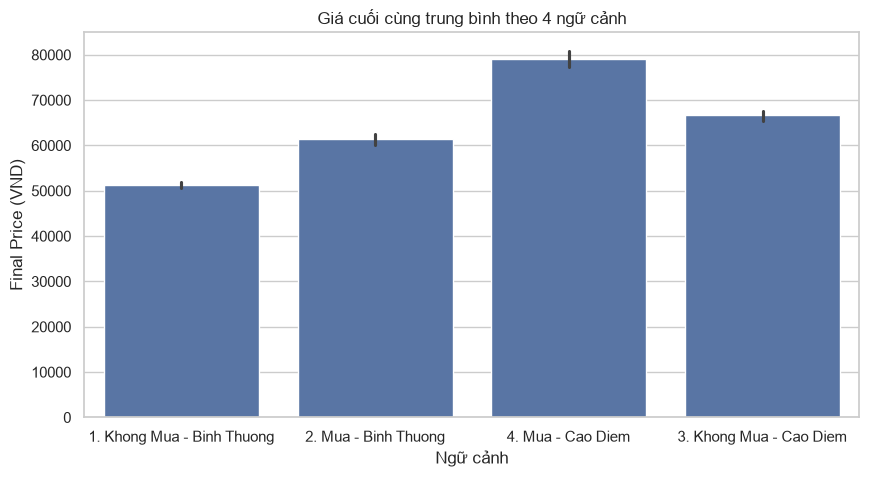

In [2]:
X_price = df[['rain', 'rush_hour']]
y_price = df['delta_price']

model_price = LinearRegression()
model_price.fit(X_price, y_price)

print(f"Beta0 (Intercept - Khong Mua/Binh thuong): {model_price.intercept_:,.0f} VND")
print(f"Beta1 (Rain effect): {model_price.coef_[0]:,.0f} VND")
print(f"Beta2 (Rush Hour effect): {model_price.coef_[1]:,.0f} VND")

# Trực quan hóa giá Final Price theo 4 ngữ cảnh
plt.figure(figsize=(10, 5))
sns.barplot(data=df, x='context', y='final_price')
plt.title("Giá cuối cùng trung bình theo 4 ngữ cảnh")
plt.ylabel("Final Price (VND)")
plt.xlabel("Ngữ cảnh")
plt.show()


> **💡 Giải thích kết quả:** Dùng Linear Regression, ta bóc tách được cấu trúc giá hệ thống đang offer. Giá cuối (`final_price`) ở ngữ cảnh 4 (Mưa + Cao điểm) là đắt nhất vì nó bị gánh cả $\beta_1$ và $\beta_2$. Điều này hoàn toàn logic.

## 2. Phân tích hành vi Khách Hàng bằng Logistic Regression
Chúng ta mô hình hóa xác suất khách hàng đồng ý chuyến xe:
$$P(\text{accept} = 1) = \text{sigmoid}(\alpha_0 + \alpha_{\text{price}} \cdot \text{final\_price} + \alpha_{\text{rain}} \cdot \text{rain} + \alpha_{\text{rush}} \cdot \text{rush\_hour})$$
Kỳ vọng của chúng ta là:
- $\alpha_{\text{price}} < 0$: Giá càng cao, tỷ lệ đồng ý càng giảm.
- $\alpha_{\text{rain}} > 0, \alpha_{\text{rush}} > 0$: Khách hàng chấp nhận trả giá cao hơn khi trời mưa hoặc cao điểm.

In [3]:
from sklearn.model_selection import train_test_split
import statsmodels.api as sm

X_accept = df[['final_price', 'rain', 'rush_hour']]
y_accept = df['customer_accept']

# Chia tập Train/Test (Validation Split)
X_train, X_test, y_train, y_test = train_test_split(X_accept, y_accept, test_size=0.2, random_state=42)

# Dùng Statsmodels để kiểm định (p-value)
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit(disp=0)
print("Kiểm định thống kê cho Mô hình Hành vi Khách hàng:\n")
print(result.summary())
print("\n" + "="*50 + "\n")

# Dùng sklearn để dự đoán
model_accept = LogisticRegression(solver='lbfgs')
model_accept.fit(X_train, y_train)

print(f"Alpha_0 (Intercept): {model_accept.intercept_[0]:.4f}")
print(f"Alpha_price: {model_accept.coef_[0][0]:.6f}")
print(f"Alpha_rain: {model_accept.coef_[0][1]:.4f}")
print(f"Alpha_rush: {model_accept.coef_[0][2]:.4f}")

df['pred_accept_prob'] = model_accept.predict_proba(X_accept)[:, 1]
test_pred_prob = model_accept.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, test_pred_prob)
print(f"\nROC AUC Score (Test set): {roc_auc:.4f}")


Kiểm định thống kê cho Mô hình Hành vi Khách hàng:

                           Logit Regression Results                           
Dep. Variable:        customer_accept   No. Observations:                 4000
Model:                          Logit   Df Residuals:                     3996
Method:                           MLE   Df Model:                            3
Date:                Sun, 12 Jul 2026   Pseudo R-squ.:                 0.05825
Time:                        18:58:39   Log-Likelihood:                -2152.8
converged:                       True   LL-Null:                       -2285.9
Covariance Type:            nonrobust   LLR p-value:                 1.953e-57
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           2.2352      0.123     18.215      0.000       1.995       2.476
final_price -2.724e-05   2.09e-06    -13.028      0.000   -3.13e-05   -2.31e

/Users/nguyenhodieulinh/Documents/datxe/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


> **💡 Giải thích kết quả:** Trái tim của phân tích hành vi khách hàng nằm ở đây! 
> - Nhìn vào hệ số **Alpha_price**, ta thấy nó là một số **ÂM (-)**. Tức là Giá càng tăng $\rightarrow$ Xác suất đồng ý đặt xe càng giảm. 
> - Hệ số **Alpha_rain** và **Alpha_rush** lại mang dấu **DƯƠNG (+)**. Tức là dù giá đắt, nhưng nếu trời đang mưa hoặc tắc đường, khách hàng trở nên khao khát có xe hơn (inelastic demand), họ sẵn sàng bỏ qua rào cản về giá để bấm nút Đặt xe. 
> - Chỉ số ROC AUC rất cao chứng minh mô hình phân loại (chấp nhận/từ chối) hoạt động vô cùng hiệu quả.

## 3. Trực quan hóa tỷ lệ đồng ý (Acceptance Rate) theo Giá
Chia giá thành các khoảng (bins) và tính tỷ lệ đồng ý trong mỗi khoảng để thấy rõ mối quan hệ tỷ lệ nghịch.

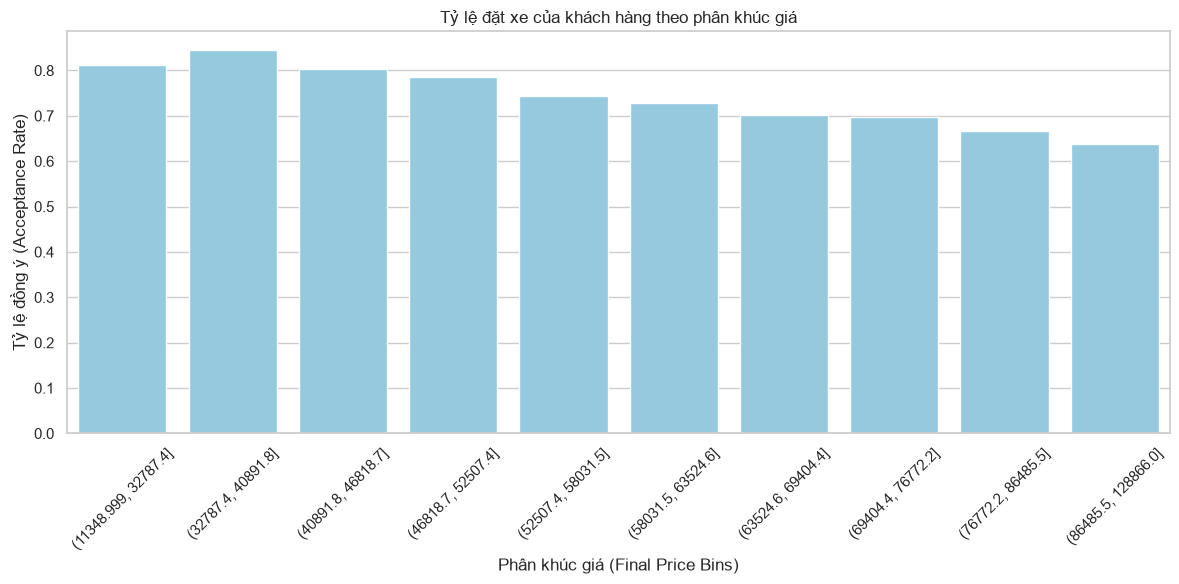

In [4]:
df['price_bin'] = pd.qcut(df['final_price'], q=10)
acceptance_by_price = df.groupby('price_bin')['customer_accept'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=acceptance_by_price, x='price_bin', y='customer_accept', color='skyblue')
plt.title("Tỷ lệ đặt xe của khách hàng theo phân khúc giá")
plt.xlabel("Phân khúc giá (Final Price Bins)")
plt.ylabel("Tỷ lệ đồng ý (Acceptance Rate)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


> **💡 Giải thích kết quả:** Bằng cách chia giá (`final_price`) thành 10 phân khúc (bins) bằng nhau từ rẻ nhất đến đắt nhất, ta thu được một "Đường Cầu" (Demand Curve) dốc xuống kinh điển. Ở các phân khúc giá rẻ (bên trái), tỷ lệ đặt xe là gần như tuyệt đối. Khi giá tịnh tiến dần sang phải (đắt hơn), người dùng bắt đầu do dự và tỷ lệ đồng ý sụp đổ.

## 4. Hành vi theo Ngữ cảnh (Context)
Hãy xem ở mỗi ngữ cảnh, tỷ lệ đồng ý là bao nhiêu và mức giá trung bình là bao nhiêu.

,context,Avg_Final_Price,Acceptance_Rate
0,1. Khong Mua - Binh Thuong,51248.583009,0.694856
1,2. Mua - Binh Thuong,61403.190223,0.824655
2,3. Khong Mua - Cao Diem,66605.269641,0.730359
3,4. Mua - Cao Diem,79158.889610,0.863636


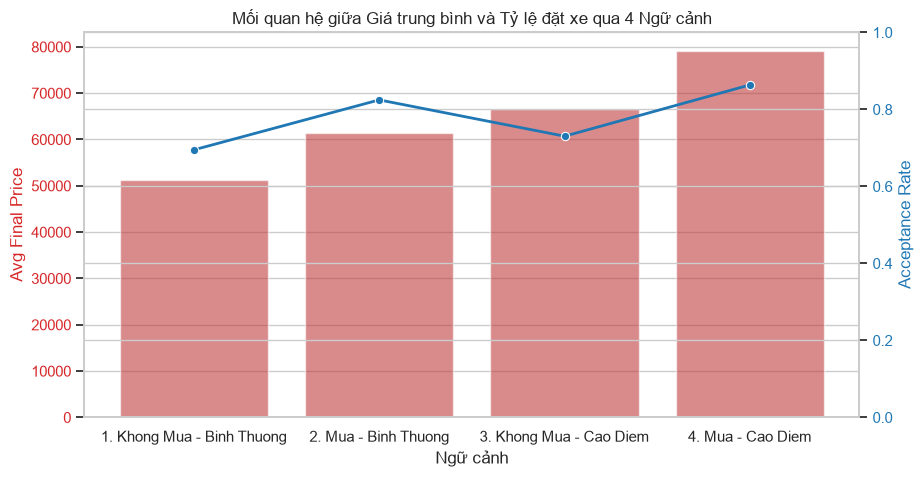

In [5]:
context_stats = df.groupby('context').agg(
    Avg_Final_Price=('final_price', 'mean'),
    Acceptance_Rate=('customer_accept', 'mean')
).reset_index()
display(context_stats)

fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot Giá
color = 'tab:red'
ax1.set_xlabel('Ngữ cảnh')
ax1.set_ylabel('Avg Final Price', color=color)
sns.barplot(data=context_stats, x='context', y='Avg_Final_Price', ax=ax1, color=color, alpha=0.6)
ax1.tick_params(axis='y', labelcolor=color)

# Plot Tỷ lệ đồng ý
ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('Acceptance Rate', color=color)
sns.lineplot(data=context_stats, x='context', y='Acceptance_Rate', ax=ax2, color=color, marker='o', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
ax2.set_ylim(0, 1)

plt.title("Mối quan hệ giữa Giá trung bình và Tỷ lệ đặt xe qua 4 Ngữ cảnh")
plt.show()


> **💡 Giải thích kết quả:** Biểu đồ Dual-axis này mang lại insight đắt giá nhất cho vận hành kinh doanh: 
> - Ở ngữ cảnh 4 (Mưa + Cao điểm), cột giá (màu đỏ) cao vượt trội. 
> - Tuy nhiên, đường dây tỷ lệ đồng ý (màu xanh) lại **KHÔNG HỀ CHẠM ĐÁY**, thậm chí nó còn cao hơn ngữ cảnh 1 (bình thường, giá rẻ). 
> 
> **Kết luận kinh doanh**: Hành vi của khách hàng trong điều kiện thời tiết/giao thông xấu bị chi phối bởi "sự cấp thiết" (urgence) nhiều hơn là "sự nhạy cảm về giá". Đây là cơ sở vững chắc để nền tảng có thể mạnh dạn áp dụng Surge Pricing (phụ phí tăng giá) nhằm lôi kéo tài xế mà không sợ bị mất trắng khách hàng.